## Ejemplo práctico con GridSearchCV

In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Cargar datos
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Definir modelo y grilla de hiperparámetros
tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Búsqueda en grilla con validación cruzada
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Mejores hiperparámetros y rendimiento
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor puntuación: {grid_search.best_score_:.4f}")

Mejores parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Mejor puntuación: 0.9281


## Implementación de regularización en Scikit-learn

In [2]:
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generar datos sintéticos
X, y = make_regression(n_samples=100, n_features=20, noise=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Modelo con regularización L1 (Lasso)
lasso = Lasso(alpha=0.1) # Ajustar alpha según necesidad
lasso.fit(X_train, y_train)

# Evaluar el modelo
y_pred = lasso.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Error cuadrático medio: {mse:.4f}")

# Ver cuántos coeficientes se redujeron a cero
n_zeros = sum(lasso.coef_ == 0)
print(f"Coeficientes eliminados: {n_zeros} de {len(lasso.coef_)}")

Error cuadrático medio: 0.3709
Coeficientes eliminados: 9 de 20


## Ejemplo con GridSearchCV y Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generar datos sintéticos
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Definir modelo y grilla de hiperparámetros
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Búsqueda en grilla con validación cruzada
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Mejores hiperparámetros y rendimiento
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor puntuación: {grid_search.best_score_:.4f}")

Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Mejor puntuación: 0.9187


## Ejemplo de grilla de parámetros con SVM

In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargar datos
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Escalar datos (importante para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir modelo y grilla de hiperparámetros
svm = SVC(random_state=42)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear', 'poly']
}

# Búsqueda en grilla con validación cruzada
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Mejores hiperparámetros y rendimiento
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor puntuación: {grid_search.best_score_:.4f}")

Mejores parámetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mejor puntuación: 0.9789


## Ejemplo práctico con regresión logística

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Generar datos desbalanceados (10% clase positiva, 90% clase negativa)
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.9, 0.1], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Modelo sin balanceo
model_unbalanced = LogisticRegression(random_state=42)
model_unbalanced.fit(X_train, y_train)
y_pred_unbalanced = model_unbalanced.predict(X_test)

# Modelo con balanceo de clases
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

# Comparar resultados
print("Modelo sin balanceo:")
print(classification_report(y_test, y_pred_unbalanced))
print("\nModelo con balanceo:")
print(classification_report(y_test, y_pred_balanced))

Modelo sin balanceo:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       226
           1       0.47      0.33      0.39        24

    accuracy                           0.90       250
   macro avg       0.70      0.65      0.67       250
weighted avg       0.89      0.90      0.89       250


Modelo con balanceo:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       226
           1       0.39      0.79      0.52        24

    accuracy                           0.86       250
   macro avg       0.68      0.83      0.72       250
weighted avg       0.92      0.86      0.88       250



## LIVE CODING 1

Vamos a optimizar un modelo de clasificación paso a paso, incorporando selección de variables, ajuste de hiperparámetros y balanceo de clases.

1. Cargar un dataset (churn.csv) con la columna objetivo: "Se va / No se va".


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Descripción de Columnas - Telco Customer Churn

| Columna | Tipo de Variable | Descripción |
|----------|------------------|-------------|
| customerID | ID | Identificador único del cliente |
| gender | Categórica | Género del cliente |
| SeniorCitizen | Binaria (0/1) | Indica si es adulto mayor (1) o no (0) |
| Partner | Binaria (Yes/No) | Indica si tiene pareja |
| Dependents | Binaria (Yes/No) | Indica si tiene dependientes a cargo |
| tenure | Numérica | Meses que el cliente lleva con la empresa |
| PhoneService | Binaria (Yes/No) | Indica si tiene servicio telefónico |
| MultipleLines | Categórica | Indica si posee múltiples líneas telefónicas |
| InternetService | Categórica | Tipo de servicio de internet (DSL, Fiber optic, None) |
| OnlineSecurity | Categórica | Servicio de seguridad online |
| OnlineBackup | Categórica | Servicio de respaldo online |
| DeviceProtection | Categórica | Servicio de protección de dispositivos |
| TechSupport | Categórica | Servicio de soporte técnico |
| StreamingTV | Categórica | Servicio de TV en streaming |
| StreamingMovies | Categórica | Servicio de películas en streaming |
| Contract | Categórica | Tipo de contrato (mensual, anual, bianual) |
| PaperlessBilling | Binaria (Yes/No) | Usa facturación electrónica |
| PaymentMethod | Categórica | Método de pago utilizado |
| MonthlyCharges | Numérica | Cargo mensual del servicio |
| TotalCharges | Numérica | Cargo total acumulado |
| Churn | Variable Objetivo | Indica si el cliente abandona la empresa (Yes/No) |

2. Realizar un análisis exploratorio breve para identificar variables relevantes.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [14]:
df = df.drop("customerID", axis=1)

3. Dividir los datos en entrenamiento y prueba.

**Separamos variables**

In [15]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Preprocesamiento**

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols), # passthrough es literalmente “pásalo tal cual”. Utilizaré un árbol de decisiones
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

4. Entrenar un modelo base con DecisionTreeClassifier sin optimización.

In [18]:
from sklearn.tree import DecisionTreeClassifier

pipe_base = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

pipe_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

**Evaluación**

Matriz de confusión:
 [[838 197]
 [185 189]]

Reporte:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.51      0.50       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



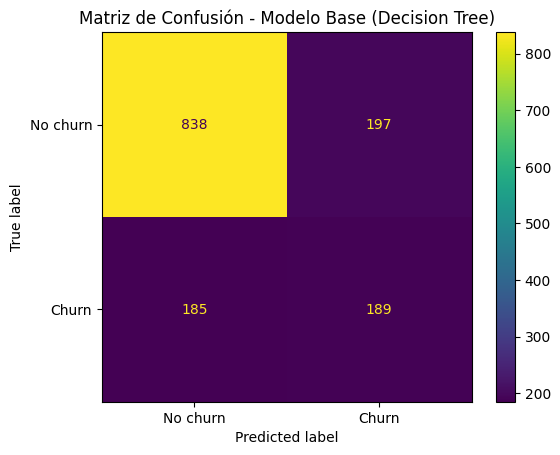

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_base = pipe_base.predict(X_test)

# Matriz de confusión (numérica)
cm = confusion_matrix(y_test, y_pred_base)
print("Matriz de confusión:\n", cm)

# Reporte
print("\nReporte:\n", classification_report(y_test, y_pred_base))

display_labels=[0, 1]

# Matriz de confusión (gráfica)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churn"])
disp.plot(values_format="d")
plt.title("Matriz de Confusión - Modelo Base (Decision Tree)")
plt.show()

**Observaciones:**
* 838 clientes que se quedan → correctamente clasificados
* 197 clientes que se quedan → el modelo predijo que se iban
* 185 clientes que se iban → el modelo no los detectó
* 189 clientes que se iban → correctamente detectados



*¿Dónde está el problema?*

clase 1 (Churn):
* Recall = 0.51
* Precision = 0.49
* F1 = 0.50

Eso significa que: El modelo solo está detectando el 51% de los clientes que realmente se van. Desde negocio, eso es bajo.
Está dejando escapar casi la mitad del churn real.

Porque el dataset está desbalanceado:
* 1035 No churn
* 374 Churn

El árbol naturalmente favorece la clase mayoritaria.

Y esto es exactamente lo que quieres mostrar en la demo: “Si no consideramos el desbalance, el modelo aprende más de la clase dominante.”

La accuracy (0.73) engaña.

Pero:

* F1 clase 0 → 0.81
* F1 clase 1 → 0.50

El modelo funciona bien para los que se quedan, pero es malo para detectar fuga.

Pregunta: “Si yo fuera el gerente, no me interesa predecir quién se queda.
Me interesa detectar quién se va.?"

5. Aplicar SelectKBest para reducir dimensionalidad.


In [20]:
from sklearn.feature_selection import SelectKBest, chi2

pipe_select = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=chi2, k=20)), # selecciona las 20 variables más relacionadas con la variable objetivo, usando la prueba estadística chi-cuadrado para medir esa asociación.
    ("model", DecisionTreeClassifier(random_state=42))
])

pipe_select.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [21]:
y_pred_select = pipe_select.predict(X_test)

print(classification_report(y_test, y_pred_select))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.51      0.50       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



Matriz de confusión:
 [[838 197]
 [185 189]]

Reporte:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.51      0.50       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409

Quedaron casi igual que el modelo base:
* Accuracy sube un poquito: 0.73 → 0.74
* Para churn (clase 1):
  - precision 0.49 → 0.50
  - recall se queda en 0.51
  - f1 se queda en 0.50

Reducir variables a 20 no mejoró la detección de churn (que es lo importante), pero sí te dejó un modelo un poquito más “limpio” y con accuracy apenas mayor.

Es normal: a veces SelectKBest ayuda, a veces deja todo parecido. Por eso el siguiente paso (GridSearch y/o class_weight) suele mover la aguja.

Matriz de confusión:
 [[838 197]
 [185 189]]


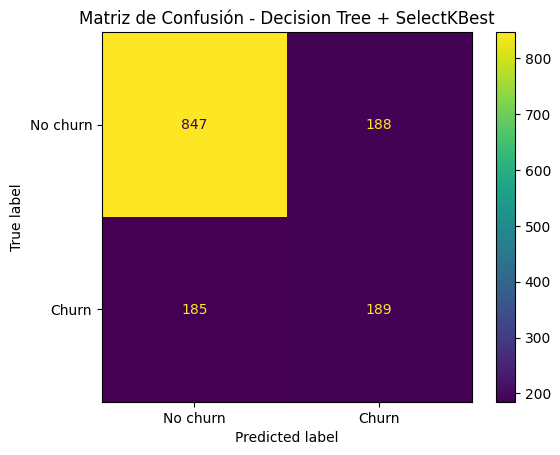

In [22]:
# Matriz
cm_select = confusion_matrix(y_test, y_pred_select)

# Mostrar en consola
print("Matriz de confusión:\n", cm)

# Gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm_select,
                              display_labels=["No churn", "Churn"])

disp.plot(values_format="d")
plt.title("Matriz de Confusión - Decision Tree + SelectKBest")
plt.show()

6. Usar GridSearchCV para ajustar hiperparámetros (max_depth, min_samples_split).

In [23]:
from sklearn.model_selection import GridSearchCV

# model__max_depth: qué tan profundo puede crecer el árbol
#  * 3 = árbol simple (menos sobreajuste)
#  * 10 o None = árbol más complejo (puede sobreajustar)
# model__min_samples_split: mínimo de filas para poder “partir” un nodo
#  * 2 = parte con facilidad (más complejo)
#  * 10 = más conservador (más simple)
#
# En total se están probando 4 × 3 = 12 combinaciones.
param_grid = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10]
}

pipe_grid = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=chi2)),
    ("model", DecisionTreeClassifier(random_state=42))
])

# cv=5: hace validación cruzada en 5 partes
# (entrena 5 veces por combinación, para no depender de “una sola partición”)
#
# scoring="f1": elige la mejor combinación según F1
# (útil en churn porque el dataset está desbalanceado; accuracy puede engañar)
#
# n_jobs=-1: usa todos los núcleos del computador para acelerar
grid = GridSearchCV(
    pipe_grid,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

**Mejor modelo**

In [24]:
print(grid.best_params_)
print(grid.best_score_)
best_model = grid.best_estimator_

{'model__max_depth': 5, 'model__min_samples_split': 2}
0.5650675671257945


**Evaluar**

In [25]:
y_pred_grid = grid.predict(X_test)
print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.51      0.50       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409

|              | Antes | Con GridSearch |
| ------------ | ----- | -------------- |
| Recall churn | 0.51  | **0.57**       |
| F1 churn     | 0.50  | **0.60**       |


Mejoró bastante la detección de churn

**Precision (0.63)**:
De todos los clientes que el modelo predijo que se iban,
el 63% realmente se iban.

Cuando llamas para ofrecer retención, no estás molestando tanto a clientes equivocados.

**Recall (0.57)**:
El modelo detecta el 57% de los clientes que realmente se iban.

Está capturando más churn real que antes (51%).
Todavía deja escapar algunos, pero mejora.

**F1-score (0.60)**:
Es el equilibrio entre precision y recall.

Como el problema está desbalanceado, F1 es mejor indicador que accuracy.

Matriz de confusión:
 [[838 197]
 [185 189]]


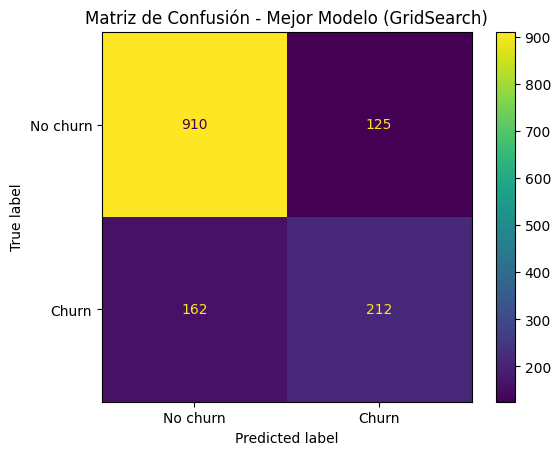

In [26]:
# Matriz
cm_grid = confusion_matrix(y_test, y_pred_grid)
print("Matriz de confusión:\n", cm)

# Gráfico
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_grid,
    display_labels=["No churn", "Churn"]
)

disp.plot(values_format="d")
plt.title("Matriz de Confusión - Mejor Modelo (GridSearch)")
plt.show()

7. Aplicar class_weight='balanced' y comparar rendimiento.

In [27]:
param_grid_balanced = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__class_weight": [None, "balanced"] #<-- se agrega 2 escenarios : None: entrenar “normal”, "balanced": darle más peso a la clase minoritaria (churn) para que el árbol la tome más en serio.
}
# Esto ahora prueba 4 × 3 × 2 = 24 combinaciones (el doble que antes).
grid_bal = GridSearchCV(
    pipe_grid,
    param_grid_balanced,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_bal.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

**Mejor modelo**

In [28]:
print(grid_bal.best_params_)
print(grid_bal.best_score_)
best_model_bal = grid_bal.best_estimator_

{'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_split': 2}
0.6204258562219814


**Evaluar**

In [29]:
y_pred_bal = grid_bal.predict(X_test)
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


**Clase 0 (No churn):**
Precision 0.90 / Recall 0.73
Esto muestra que ahora el modelo está menos “amigable” con la clase 0: se equivoca más marcando churn.

**Para la clase 1 (Churn)**, el modelo ahora detecta el 78% de los clientes que realmente se iban, por lo que deja escapar pocos. Sin embargo, cuando predice que alguien se va, solo acierta en un 51%, es decir, habrá varios falsos positivos.

El F1 = 0.62 refleja ese equilibrio: mejora respecto al modelo anterior porque el recall subió bastante, aunque la precisión bajó.

Matriz de confusión:
 [[758 277]
 [ 81 293]]


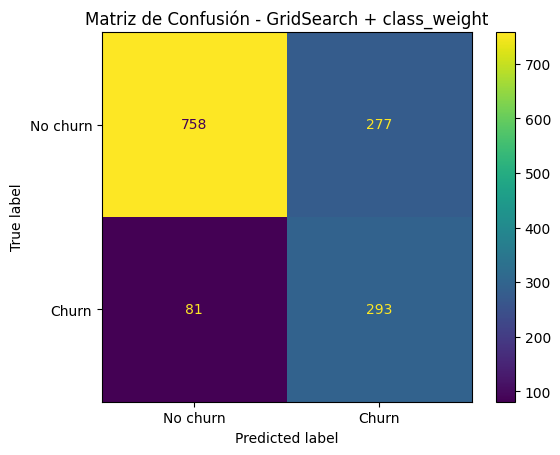

In [30]:
# Matriz
cm_bal = confusion_matrix(y_test, y_pred_bal)
print("Matriz de confusión:\n", cm_bal)

# Gráfico
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bal,
    display_labels=["No churn", "Churn"]
)

disp.plot(values_format="d")
plt.title("Matriz de Confusión - GridSearch + class_weight")
plt.show()

8. Evaluar el mejor modelo con matriz de confusión y classification_report.

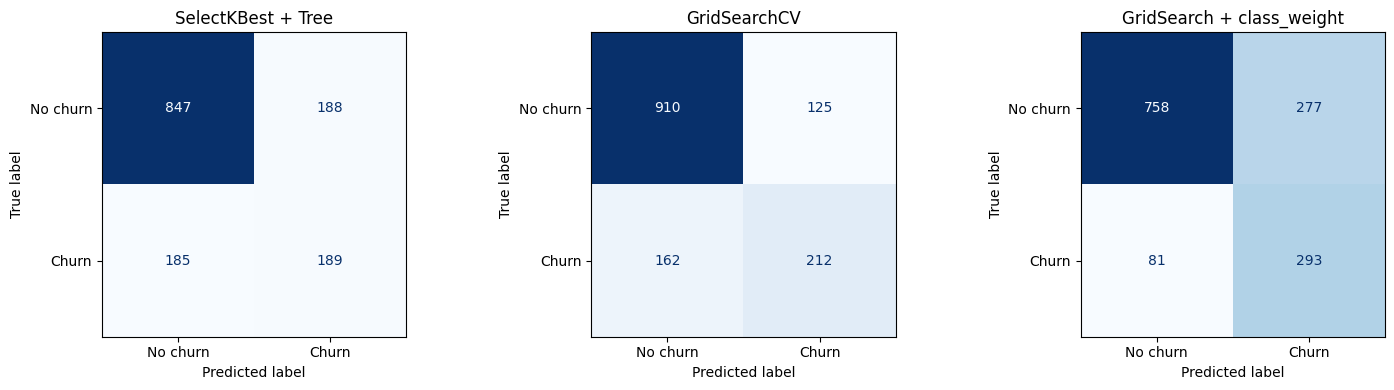

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Labels (ajusta si quieres 0/1)
labels = ["No churn", "Churn"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(confusion_matrix=cm_select, display_labels=labels)\
    .plot(ax=axes[0], values_format="d", cmap="Blues", colorbar=False)
axes[0].set_title("SelectKBest + Tree")

ConfusionMatrixDisplay(confusion_matrix=cm_grid, display_labels=labels)\
    .plot(ax=axes[1], values_format="d", cmap="Blues", colorbar=False)
axes[1].set_title("GridSearchCV")

ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=labels)\
    .plot(ax=axes[2], values_format="d", cmap="Blues", colorbar=False)
axes[2].set_title("GridSearch + class_weight")

plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

models = {
    "SelectKBest + Tree": y_pred_select,
    "GridSearchCV": y_pred_grid,
    "GridSearch + class_weight": y_pred_bal
}

rows = []
for name, y_pred in models.items():
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[0,1])
    # nos quedamos con la clase 1 (churn)
    rows.append({
        "Modelo": name,
        "Precision (Churn)": p[1],
        "Recall (Churn)": r[1],
        "F1 (Churn)": f1[1],
    })

df_metrics = pd.DataFrame(rows).set_index("Modelo")
df_metrics

,Precision (Churn),Recall (Churn),F1 (Churn)
Modelo,,,
SelectKBest + Tree,0.501326,0.505348,0.503329
GridSearchCV,0.629080,0.566845,0.596343
GridSearch + class_weight,0.514035,0.783422,0.620763


In [33]:
from sklearn.metrics import classification_report

print("=== SelectKBest + Tree ===")
print(classification_report(y_test, y_pred_select))

print("\n=== GridSearchCV ===")
print(classification_report(y_test, y_pred_grid))

print("\n=== GridSearch + class_weight ===")
print(classification_report(y_test, y_pred_bal))

=== SelectKBest + Tree ===
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.51      0.50       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409


=== GridSearchCV ===
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


=== GridSearch + class_weight ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71 

9. Visualizar los resultados de las diferentes combinaciones de parámetros.

In [34]:
results = pd.DataFrame(grid_bal.cv_results_)


In [35]:
results.shape

(24, 16)

In [36]:
results[["param_model__max_depth",
         "param_model__min_samples_split",
         "param_model__class_weight",
         "mean_test_score"]].sort_values("mean_test_score", ascending=False).head()

,param_model__max_depth,param_model__min_samples_split,param_model__class_weight,mean_test_score
14,3,10,balanced,0.620426
12,3,2,balanced,0.620426
13,3,5,balanced,0.620426
15,5,2,balanced,0.615055
16,5,5,balanced,0.615055


mean_test_score es el promedio del score que obtuvo esa combinación de parámetros durante la validación cruzada.

# **PARTE 2**

## Ejemplo de pipeline completo

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generar datos desbalanceados
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.8, 0.2], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Crear pipeline con escalado y modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
    # Cambiado a 'liblinear' para soportar 'l1' y 'l2'
])

# Definir grilla de hiperparámetros
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

# Búsqueda en grilla con validación cruzada
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Mejores hiperparámetros y rendimiento
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor puntuación F1: {grid_search.best_score_:.4f}")

# Evaluar en conjunto de prueba
y_pred = grid_search.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

d:\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\.venv\Lib\site-packages\sklearn\linear

Mejores parámetros: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__penalty': 'l1'}
Mejor puntuación F1: 0.7923
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       196
           1       0.77      0.61      0.68        54

    accuracy                           0.88       250
   macro avg       0.83      0.78      0.80       250
weighted avg       0.87      0.88      0.87       250



d:\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or '

## Validación cruzada estratificada

In [38]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression # Importar un modelo de ejemplo

# Configurar validación cruzada estratificada
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Inicializar un modelo (usamos LogisticRegression como ejemplo)
model = LogisticRegression(random_state=42, solver='liblinear')
# Puedes cambiar esto por otro modelo

# Iterar sobre los folds
scores = []
for train_idx, test_idx in kf.split(X, y):
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]
    # Entrenar y evaluar modelo
    model.fit(X_train_fold, y_train_fold)
    y_pred = model.predict(X_test_fold)
    scores.append(accuracy_score(y_test_fold, y_pred))

print(f"Puntuación media: {np.mean(scores):.4f}")
print(f"Desviación estándar: {np.std(scores):.4f}")

Puntuación media: 0.9020
Desviación estándar: 0.0103


## Optimización de hiperparámetros con Optuna

In [40]:
#!pip install optuna
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Split data for Optuna: X_train, X_valid
X_train_opt, X_valid, y_train_opt, y_valid = train_test_split(X_train, y_train, random_state=42)

def objective(trial):
    # Definir espacio de búsqueda
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 2, 32, log=True)
    min_samples_split = trial.suggest_float('min_samples_split', 0.01, 0.5)

    # Crear y entrenar modelo
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    clf.fit(X_train_opt, y_train_opt)

    # Evaluar
    y_pred = clf.predict(X_valid)
    return accuracy_score(y_valid, y_pred)

# Ejecutar optimización
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f"Mejores hiperparámetros: {study.best_params}")
print(f"Mejor puntuación: {study.best_value:.4f}")

[I 2026-03-02 18:42:44,795] A new study created in memory with name: no-name-84ec26b7-e243-4e45-8fc4-57e2cff30e32
[I 2026-03-02 18:42:45,071] Trial 0 finished with value: 0.8882978723404256 and parameters: {'n_estimators': 163, 'max_depth': 3, 'min_samples_split': 0.045701913599410636}. Best is trial 0 with value: 0.8882978723404256.
[I 2026-03-02 18:42:45,435] Trial 1 finished with value: 0.898936170212766 and parameters: {'n_estimators': 194, 'max_depth': 32, 'min_samples_split': 0.11774037122345009}. Best is trial 1 with value: 0.898936170212766.
[I 2026-03-02 18:42:45,614] Trial 2 finished with value: 0.8882978723404256 and parameters: {'n_estimators': 110, 'max_depth': 4, 'min_samples_split': 0.048254358788063466}. Best is trial 1 with value: 0.898936170212766.
[I 2026-03-02 18:42:45,846] Trial 3 finished with value: 0.8882978723404256 and parameters: {'n_estimators': 157, 'max_depth': 7, 'min_samples_split': 0.35862656379438146}. Best is trial 1 with value: 0.898936170212766.
[I 

Mejores hiperparámetros: {'n_estimators': 85, 'max_depth': 12, 'min_samples_split': 0.19850834936858536}
Mejor puntuación: 0.9149


## Automatización del aprendizaje automático (AutoML)

In [41]:
!pip -q install h2o

H2O es un motor de machine learning que corre en Java y puede:

Trabajar con grandes volúmenes de datos

Paralelizar entrenamiento

Ejecutar algoritmos optimizados

Hacer

In [42]:
import h2o
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...


H2OStartupError: Cannot find Java. Please install the latest JRE from
http://docs.h2o.ai/h2o/latest-stable/h2o-docs/welcome.html#java-requirements

In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Target: Churn (Yes/No). Dejémoslo como factor (clasificación)
df["Churn"] = df["Churn"].astype("category")

# TotalCharges viene como texto a veces
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Pasar a H2OFrame y split train/test**

In [ ]:
hf = h2o.H2OFrame(df)

y = "Churn"
x = [c for c in hf.columns if c != y]

# Asegurar que sea clasificación
hf[y] = hf[y].asfactor()

train, test = hf.split_frame(ratios=[0.8], seed=42)

train.dim, test.dim

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


([5643, 21], [1400, 21])

**Ejecutar AutoML (prueba modelos + tuning + ensembles)**

In [ ]:
from h2o.automl import H2OAutoML

aml = H2OAutoML(
    max_runtime_secs=120,   # 2 minutos (ajusta a 300-600 si quieres mejor resultado)
    seed=42,
    sort_metric="F1"        # para churn suele ser buena idea
)

aml.train(x=x, y=y, training_frame=train)

lb = aml.leaderboard
lb.head()

AutoML progress: |
18:32:36.76: _train param, Dropping bad and constant columns: [customerID]

██████
18:32:47.427: _train param, Dropping bad and constant columns: [customerID]

███
18:32:52.774: _train param, Dropping bad and constant columns: [customerID]

███
18:33:00.533: _train param, Dropping unused columns: [customerID]

█
18:33:01.243: _train param, Dropping bad and constant columns: [customerID]

████
18:33:09.281: _train param, Dropping bad and constant columns: [customerID]

██████
18:33:19.968: _train param, Dropping bad and constant columns: [customerID]

██
18:33:23.909: _train param, Dropping bad and constant columns: [customerID]

██
18:33:27.478: _train param, Dropping bad and constant columns: [customerID]

██
18:33:31.359: _train param, Dropping unused columns: [customerID]
18:33:32.917: _train param, Dropping unused columns: [customerID]

█
18:33:34.94: _train param, Dropping bad and constant columns: [customerID]

███
18:33:39.820: _train param, Dropping bad and c

model_id,f1,auc,logloss,aucpr,mean_per_class_error,rmse,mse
GBM_grid_1_AutoML_1_20260228_183235_model_3,0.606214,0.812764,0.469945,0.597972,0.253928,0.39074,0.152678
XGBoost_grid_1_AutoML_1_20260228_183235_model_1,0.609253,0.820645,0.512964,0.612702,0.25739,0.397439,0.157958
DeepLearning_grid_1_AutoML_1_20260228_183235_model_1,0.616495,0.827663,0.454419,0.618167,0.25128,0.386574,0.149439
XGBoost_grid_1_AutoML_1_20260228_183235_model_2,0.617453,0.827329,0.471853,0.629216,0.246947,0.386722,0.149554
XGBoost_grid_1_AutoML_1_20260228_183235_model_3,0.617771,0.81916,0.575657,0.60876,0.24647,0.438791,0.192537
XGBoost_2_AutoML_1_20260228_183235,0.624479,0.829575,0.45003,0.630585,0.239981,0.382429,0.146252
DRF_1_AutoML_1_20260228_183235,0.627798,0.835521,0.477316,0.635741,0.241709,0.374752,0.140439
XGBoost_1_AutoML_1_20260228_183235,0.628907,0.839444,0.431838,0.639476,0.238185,0.375836,0.141253
DeepLearning_1_AutoML_1_20260228_183235,0.630487,0.838985,0.429125,0.638903,0.236506,0.374762,0.140446
GBM_grid_1_AutoML_1_20260228_183235_model_2,0.630631,0.835462,0.432456,0.630489,0.243217,0.375839,0.141255


**Ver el mejor modelo y evaluarlo en TEST**

In [ ]:
leader = aml.leader
print("Mejor modelo:", leader.model_id)

perf = leader.model_performance(test_data=test)
print(perf)  # métricas generales

Mejor modelo: GBM_grid_1_AutoML_1_20260228_183235_model_3
ModelMetricsBinomial: gbm
** Reported on test data. **

MSE: 0.15579118990689014
RMSE: 0.39470392689570516
LogLoss: 0.4824561187094615
Mean Per-Class Error: 0.293711598880537
AUC: 0.791241327914732
AUCPR: 0.5967538247896542
Gini: 0.582482655829464

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.29493623687104586
       No    Yes    Error    Rate
-----  ----  -----  -------  --------------
No     785   257    0.2466   (257.0/1042.0)
Yes    122   236    0.3408   (122.0/358.0)
Total  907   493    0.2707   (379.0/1400.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.294936     0.554642  207
max f2                       0.188779     0.702621  319
max f0point5                 0.419915     0.599002  98
max accuracy                 0.42686      0.799286  93
max precis

**Matriz de confusión**

In [ ]:
# Matriz de confusión con umbral por defecto
cm = perf.confusion_matrix()
cm

,No,Yes,Error,Rate
No,785.0,257.0,0.2466,(257.0/1042.0)
Yes,122.0,236.0,0.3408,(122.0/358.0)
Total,907.0,493.0,0.2707,(379.0/1400.0)


Si quieres optimizar el umbral para F1 (muy útil en churn), puedes usar el “best threshold” que sugiere H2O:

In [ ]:
# Umbral que maximiza F1 (según métricas internas)
best_thr = perf.find_threshold_by_max_metric("f1")
best_thr

0.29493623687104586

Y sacar la matriz con ese umbral:

In [ ]:
perf.confusion_matrix(thresholds=[best_thr])

,No,Yes,Error,Rate
No,785.0,257.0,0.2466,(257.0/1042.0)
Yes,122.0,236.0,0.3408,(122.0/358.0)
Total,907.0,493.0,0.2707,(379.0/1400.0)


**¿Qué modelos probó?**

In [ ]:
lb.as_data_frame().head(15)

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,f1,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GBM_grid_1_AutoML_1_20260228_183235_model_3,0.606214,0.812764,0.469945,0.597972,0.253928,0.390740,0.152678
1,XGBoost_grid_1_AutoML_1_20260228_183235_model_1,0.609253,0.820645,0.512964,0.612702,0.257390,0.397439,0.157958
2,DeepLearning_grid_1_AutoML_1_20260228_183235_m...,0.616495,0.827663,0.454419,0.618167,0.251280,0.386574,0.149439
3,XGBoost_grid_1_AutoML_1_20260228_183235_model_2,0.617453,0.827329,0.471853,0.629216,0.246947,0.386722,0.149554
4,XGBoost_grid_1_AutoML_1_20260228_183235_model_3,0.617771,0.819160,0.575657,0.608760,0.246470,0.438791,0.192537
5,XGBoost_2_AutoML_1_20260228_183235,0.624479,0.829575,0.450030,0.630585,0.239981,0.382429,0.146252
6,DRF_1_AutoML_1_20260228_183235,0.627798,0.835521,0.477316,0.635741,0.241709,0.374752,0.140439
7,XGBoost_1_AutoML_1_20260228_183235,0.628907,0.839444,0.431838,0.639476,0.238185,0.375836,0.141253
8,DeepLearning_1_AutoML_1_20260228_183235,0.630487,0.838985,0.429125,0.638903,0.236506,0.374762,0.140446
9,GBM_grid_1_AutoML_1_20260228_183235_model_2,0.630631,0.835462,0.432456,0.630489,0.243217,0.375839,0.141255


* AutoML probó varios algoritmos y combinaciones automáticamente.
* Nos deja un ranking (leaderboard) y elige un "leader".
* Después evaluamos en test y miramos matriz de confusión y F1.

Aunque parezca “más automático”, no reemplaza criterio:
* Puede sobreajustar si no controlas.
* Puede optimizar una métrica equivocada.
* No entiende el negocio.

## LIVE CODING 2

Vamos a entrenar un modelo de clasificación usando Random Forest, optimizando hiperparámetros con Optuna, y luego analizaremos la importancia de cada uno y la performance final

1. Cargar y preprocesar el dataset (make_classification o un CSV propio).



In [ ]:
#!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1) Cargar dataset UCI (Original)
data = fetch_ucirepo(id=15)

In [ ]:
y.value_counts()

,count
Class,
2,458
4,241


* 2 → (Benigno)
* 4 → (Maligno)

In [ ]:
X = data.data.features.copy()
y = data.data.targets.copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X.shape)

(699, 9)


In [ ]:
X.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


Los modelos basados en árboles no requieren escalamiento, porque no usan distancias ni optimizan gradientes; funcionan con reglas de partición.

In [ ]:
X.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0


In [ ]:
# Pipeline con StandardScaler
pipe_inicial = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(random_state=42))
])

In [ ]:
pipe_inicial.fit(X_train, y_train.values.ravel())
y_pred_inicial = pipe_inicial.predict(X_test)

In [ ]:
print("=== RandomForestClassifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_inicial))
print(classification_report(y_test, y_pred_inicial))


=== RandomForestClassifier ===
Accuracy: 0.95
Matriz confusión:
 [[88  4]
 [ 3 45]]
              precision    recall  f1-score   support

           2       0.97      0.96      0.96        92
           4       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140



Matriz confusión:
 [[88  4]
 [ 3 45]]


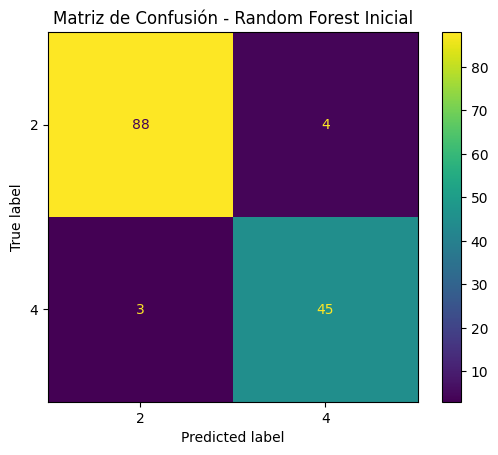

In [ ]:
print("Matriz confusión:\n", confusion_matrix(y_test, y_pred_inicial))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_inicial), display_labels=pipe_inicial.named_steps['rf'].classes_)
disp.plot(values_format="d")
plt.title("Matriz de Confusión - Random Forest Inicial")
plt.show()

2. Definir función objetivo para Optuna (accuracy sobre validación).


In [ ]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.3 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    # Convert y_train to a 1D array and use make_scorer for f1 with pos_label=4
    score = cross_val_score(
        model, X_train, y_train.values.ravel(),
        cv=5,
        scoring=make_scorer(f1_score, pos_label=4),
        n_jobs=-1
    ).mean()

    return score

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best parameters:", study.best_params)

[I 2026-02-28 20:24:22,110] A new study created in memory with name: no-name-e094f8d7-fb4f-4ac3-802f-c6f4d9c6b964
[I 2026-02-28 20:24:24,239] Trial 0 finished with value: 0.9645348827893796 and parameters: {'n_estimators': 221, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9645348827893796.
[I 2026-02-28 20:24:26,412] Trial 1 finished with value: 0.9538020446881206 and parameters: {'n_estimators': 201, 'max_depth': 20, 'min_samples_split': 14, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9645348827893796.
[I 2026-02-28 20:24:29,415] Trial 2 finished with value: 0.9539546276508301 and parameters: {'n_estimators': 324, 'max_depth': 16, 'min_samples_split': 19, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.9645348827893796.
[I 2026-02-28 20:24:30,880] Trial 3 finished with value: 0.9538020446881206 and parameters: {'n_estimators': 156, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 0 with value

Best parameters: {'n_estimators': 221, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 3}


Qué significa ese log (en simple)

“A new study created…”: Optuna creó un “experimento” (study) en memoria donde va guardando resultados.

Cada línea “Trial k finished…” es un intento distinto:

probó una combinación de hiperparámetros (n_estimators, max_depth, etc.)

calculó un score (en tu caso parece ser accuracy en validación)

y te dice si esa prueba quedó como la mejor hasta ahora.

mejor resultado

mejor trial fue el 0 con score ≈ 0.9645 y parámetros:

n_estimators = 221 → cantidad de árboles

max_depth = 3 → árboles poco profundos (modelo más “simple”, menos riesgo de sobreajuste)

min_samples_split = 2 → se permite dividir con pocos registros (default típico)

min_samples_leaf = 3 → cada hoja debe tener al menos 3 muestras (suaviza el modelo)

3. Explorar el espacio: n_estimators, max_depth, min_samples_split.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_params = {'n_estimators': 221, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 3}

rf_opt = RandomForestClassifier(**best_params, random_state=42)
rf_opt.fit(X_train, y_train.values.ravel() if hasattr(y_train, "values") else y_train)

y_pred_opt = rf_opt.predict(X_test)

print("=== RandomForest (Optuna) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Matriz confusión:\n", confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

=== RandomForest (Optuna) ===
Accuracy: 0.9571428571428572
Matriz confusión:
 [[88  4]
 [ 2 46]]
              precision    recall  f1-score   support

           2       0.98      0.96      0.97        92
           4       0.92      0.96      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.96      0.95       140
weighted avg       0.96      0.96      0.96       140



4. Visualizar los mejores parámetros y rendimiento.


In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_pos4 = make_scorer(f1_score, pos_label=4, average="binary")

def objective2(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train.values.ravel(),
        cv=cv,
        scoring=f1_pos4,
        n_jobs=-1
    ).mean()

    return score

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=30)

print("Best parameters:", study.best_params)

[I 2026-02-28 20:46:54,702] A new study created in memory with name: no-name-86d1b39c-6a7a-4c0e-8ef0-8432c7984f3a
[I 2026-02-28 20:46:58,893] Trial 0 finished with value: 0.9488827059879691 and parameters: {'n_estimators': 153, 'max_depth': 2, 'min_samples_split': 14, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.9488827059879691.
[I 2026-02-28 20:47:00,877] Trial 1 finished with value: 0.9592232451093212 and parameters: {'n_estimators': 233, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.9592232451093212.
[I 2026-02-28 20:47:02,996] Trial 2 finished with value: 0.9464185035237666 and parameters: {'n_estimators': 371, 'max_depth': 2, 'min_samples_split': 18, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.9592232451093212.
[I 2026-02-28 20:47:03,814] Trial 3 finished with value: 0.9513591793505185 and parameters: {'n_estimators': 130, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 9}. Best is trial 1 with value: 

Best parameters: {'n_estimators': 178, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 4}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

best_params = {'n_estimators': 178, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 4}

rf_opt2 = RandomForestClassifier(**best_params, random_state=42)
rf_opt2.fit(X_train, y_train.values.ravel() if hasattr(y_train, "values") else y_train)

y_pred_opt2 = rf_opt2.predict(X_test)

print("=== RandomForest (Optuna) 2 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_opt2))
print("Matriz confusión:\n", confusion_matrix(y_test, y_pred_opt2))
print(classification_report(y_test, y_pred_opt2))

=== RandomForest (Optuna) ===
Accuracy: 0.9571428571428572
Matriz confusión:
 [[88  4]
 [ 2 46]]
              precision    recall  f1-score   support

           2       0.98      0.96      0.97        92
           4       0.92      0.96      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.96      0.95       140
weighted avg       0.96      0.96      0.96       140



5. Calibrar probabilidades con CalibratedClassifierCV.


Brier (menor es mejor)
  Base      : 0.03750302729722154
  Calibrado : 0.03586901491102461

ROC AUC (solo para referencia, no mide calibración)
  Base      : 0.9891304347826086
  Calibrado : 0.9891304347826086


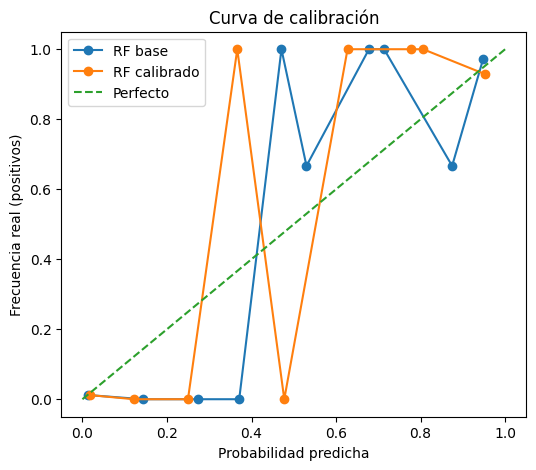

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# 1) Entrena tu modelo base (usa el que ya tienes)
# rf_opt ya entrenado o lo re-entrenamos (recomendado para dejarlo claro)
best_params = {'n_estimators': 221, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 3}
rf_base = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train.values.ravel() if hasattr(y_train, "values") else y_train)

# 2) Calibración (recomendación: CV interno)
# method: 'sigmoid' (Platt) suele ser más estable en datasets chicos
# 'isotonic' es más flexible pero puede sobreajustar si hay pocos datos
calibrador = CalibratedClassifierCV(
    estimator=rf_base,
    method="sigmoid",
    cv=5
)

calibrador.fit(X_train, y_train.values.ravel() if hasattr(y_train, "values") else y_train)

# 3) Comparar probabilidades antes vs después (para la clase positiva)
# OJO: define cuál es tu "clase positiva". En tu caso, parece ser 4.
pos_label = 4
classes = list(rf_base.classes_)
pos_idx = classes.index(pos_label)

proba_base = rf_base.predict_proba(X_test)[:, pos_idx]
proba_cal  = calibrador.predict_proba(X_test)[:, pos_idx]

y_true = (y_test.values.ravel() if hasattr(y_test, "values") else y_test)
y_true_bin = (y_true == pos_label).astype(int)

# 4) Métricas típicas para calibración
print("Brier (menor es mejor)")
print("  Base      :", brier_score_loss(y_true_bin, proba_base))
print("  Calibrado :", brier_score_loss(y_true_bin, proba_cal))

print("\nROC AUC (solo para referencia, no mide calibración)")
print("  Base      :", roc_auc_score(y_true_bin, proba_base))
print("  Calibrado :", roc_auc_score(y_true_bin, proba_cal))

# 5) Curva de calibración (reliability diagram)
frac_pos_base, mean_pred_base = calibration_curve(y_true_bin, proba_base, n_bins=10, strategy="uniform")
frac_pos_cal,  mean_pred_cal  = calibration_curve(y_true_bin, proba_cal,  n_bins=10, strategy="uniform")

plt.figure(figsize=(6,5))
plt.plot(mean_pred_base, frac_pos_base, marker="o", label="RF base")
plt.plot(mean_pred_cal,  frac_pos_cal,  marker="o", label="RF calibrado")
plt.plot([0,1],[0,1], linestyle="--", label="Perfecto")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia real (positivos)")
plt.title("Curva de calibración")
plt.legend()
plt.show()

El modelo ya tenía excelente capacidad de discriminación (AUC≈0.99).

La calibración mejoró levemente la calidad probabilística (Brier ↓).

Esto confirma que calibrar es útil cuando queremos que las probabilidades reflejen riesgo real.

6. Usar SHAP para interpretar las predicciones finales.

In [ ]:
!pip -q install shap

Crear el explainer

Usa el modelo final (idealmente el optimizado antes de calibración, porque SHAP explica el modelo base, no el calibrador).

In [ ]:
import shap

# Usamos el modelo final entrenado (rf_opt)
explainer = shap.TreeExplainer(rf_opt)

# SHAP values
shap_values = explainer.shap_values(X_test)

In [ ]:
rf_opt.classes_

array([2, 4])

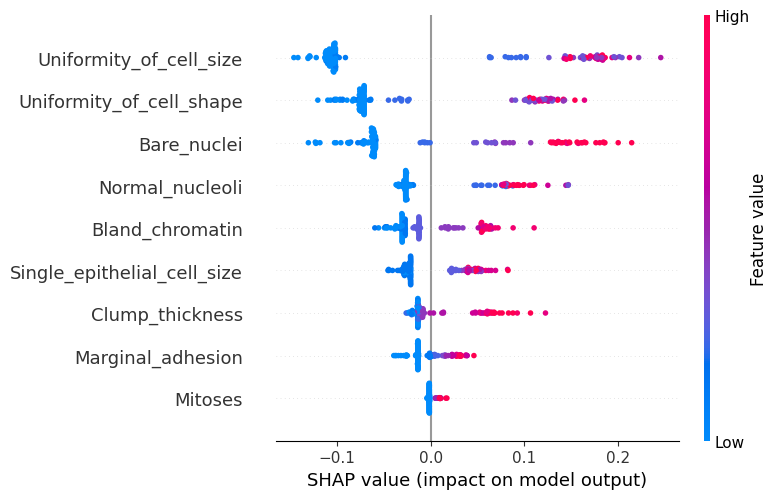

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test)

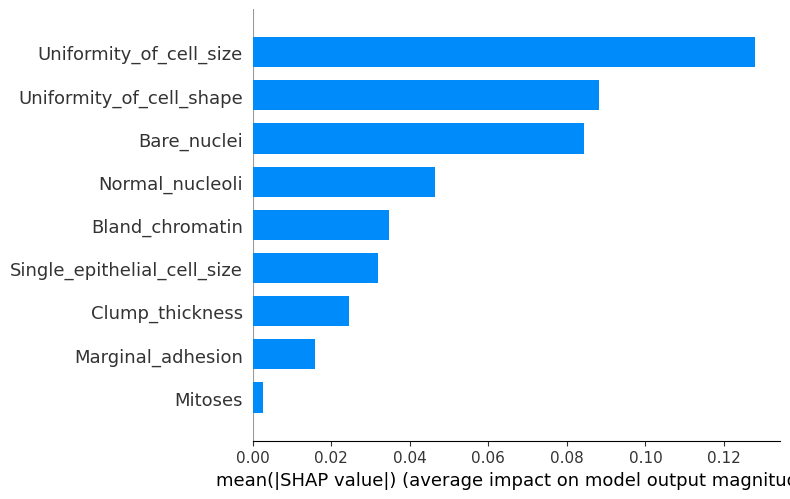

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

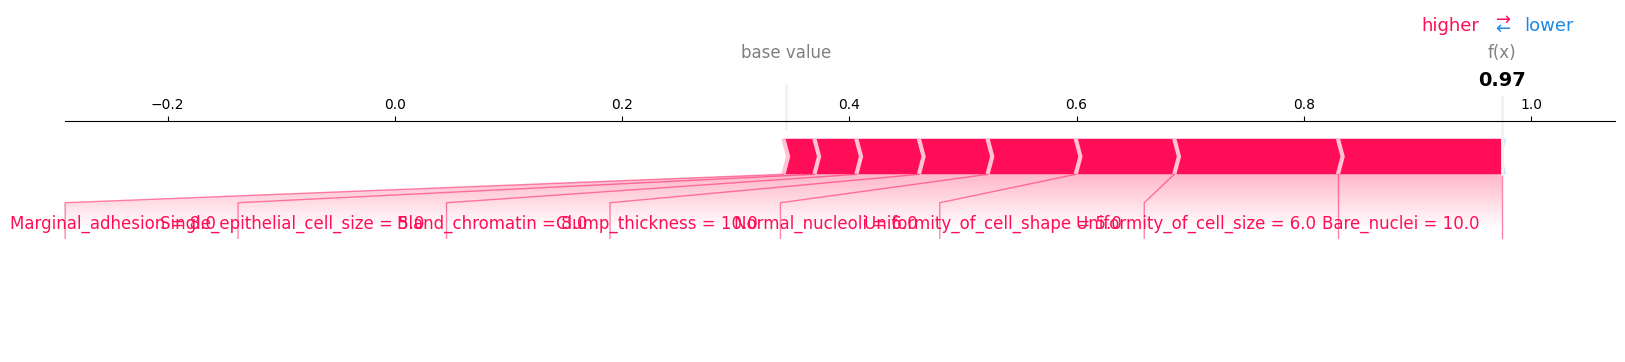

In [ ]:
idx = 5  # el caso que quieras analizar

shap.force_plot(
    explainer.expected_value[1],
    shap_values[idx, :, 1],
    X_test.iloc[idx],
    matplotlib=True
)